#**Optimización de Procesos y Eficiencia Energética**

##**Objetivo del proyecto**

Este proyecto consiste en analizar el funcionamiento de una planta de generación energética mediante ciclo combinado (CCP)

##**Descripción del dataset**

El conjunto de datos contiene 9568 puntos de datos recopilados de una central eléctrica de ciclo combinado durante 6 años (2006-2011), cuando la central estaba configurada para operar a plena carga. Las características consisten en variables ambientales promedio por hora: temperatura (T), presión ambiente (PA), humedad relativa (HR) y vacío de escape (V) para predecir la producción neta de energía eléctrica por hora (EP) de la central. Una central eléctrica de ciclo combinado (CCPP) está compuesta por turbinas de gas (GT), turbinas de vapor (ST) y generadores de vapor de recuperación de calor. En una CCPP, la electricidad es generada por turbinas de gas y vapor, que se combinan en un ciclo, y se transfiere de una turbina a otra. Si bien el vacío se recopila de la turbina de vapor y tiene un efecto sobre ella, las otras tres variables ambientales afectan el rendimiento de la GT. Para la comparabilidad con nuestros estudios de referencia y para permitir la realización de pruebas estadísticas de 5x2 pliegues, proporcionamos los datos aleatorizados cinco veces. Para cada reordenamiento se realiza una validación cruzada de 2 pliegues y las 10 mediciones resultantes se utilizan para las pruebas estadísticas. Proporcionamos los datos en formato .ods y .xlsx.

##**Variables:**

* **AT:** Temperatura Ambiente (ºC)
* **AP:** Presión ambiente (mbar)
* **RH:** Humedad relativa (%)
* **V:** Vacío de escape (cm Hg)
* **PE:** Salida neta de energía eléctrica por hora (MW)

##**Creación del entorno de trabajo**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

ruta = "/content/CCPP_project.csv"

df = pd.read_csv(ruta)

###Pequeño análisis exploratorio

In [2]:
print(df.shape)
print(f"\n{"-"*70}\n")
print(df.columns)
print(f"\n{"-"*70}\n")
print(df.dtypes)

(9568, 6)

----------------------------------------------------------------------

Index(['Unnamed: 0', 'AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

----------------------------------------------------------------------

Unnamed: 0      int64
AT            float64
V             float64
AP            float64
RH            float64
PE            float64
dtype: object


###Eliminación de columnas innecesarias

In [3]:
df.drop(columns='Unnamed: 0', inplace=True)

##**Comenzamos con las visualizaciones**

###**Análisis de distribuciones**

<Figure size 1500x1000 with 0 Axes>

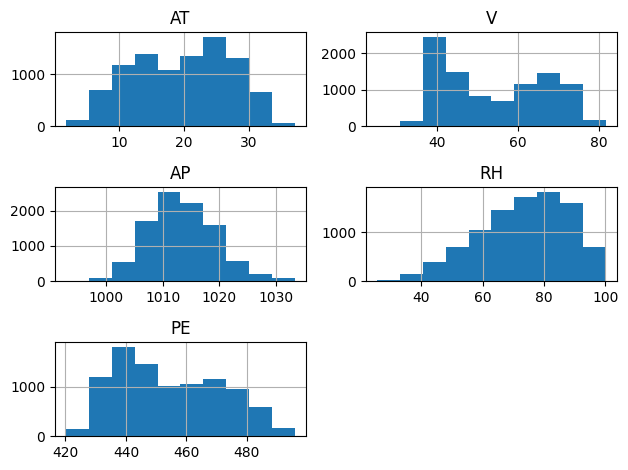

In [4]:
plt.figure(figsize=(15, 10))
df.hist()
plt.tight_layout()
plt.show()

###**Visualización 1. Distribución de la Salida de Energía (PE)**

Text(0, 0.5, 'Frecuencia')

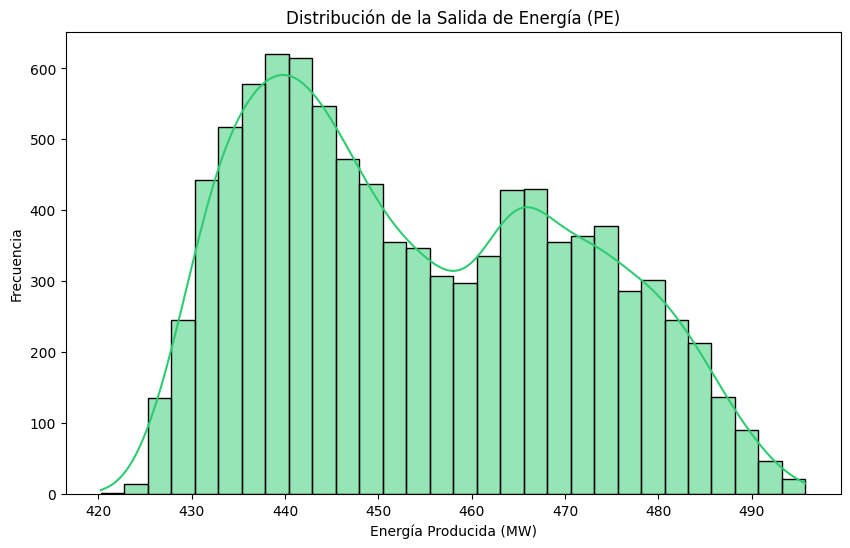

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['PE'], kde=True, color='#2ecc71', bins=30)
plt.title('Distribución de la Salida de Energía (PE)')
plt.xlabel('Energía Producida (MW)')
plt.ylabel('Frecuencia')

Vemos una distribución **bimodal** (dos picos). Esto es típico en plantas de energía que trabajan en regímenes de "Base" (máxima potencia cerca de 480-490 MW) y "Punta/Carga Parcial" (alrededor de 440 MW).

El modelo debe ser capaz de distinguir entre estos dos estados de operación. No hay valores atípicos (outliers) evidentes que puedan sesgar el entrenamiento.

###**Visualización 2. Análisis de Relaciones entre las diferentes variables**

####**AT vs PE**

/tmp/ipykernel_5590/1695460746.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


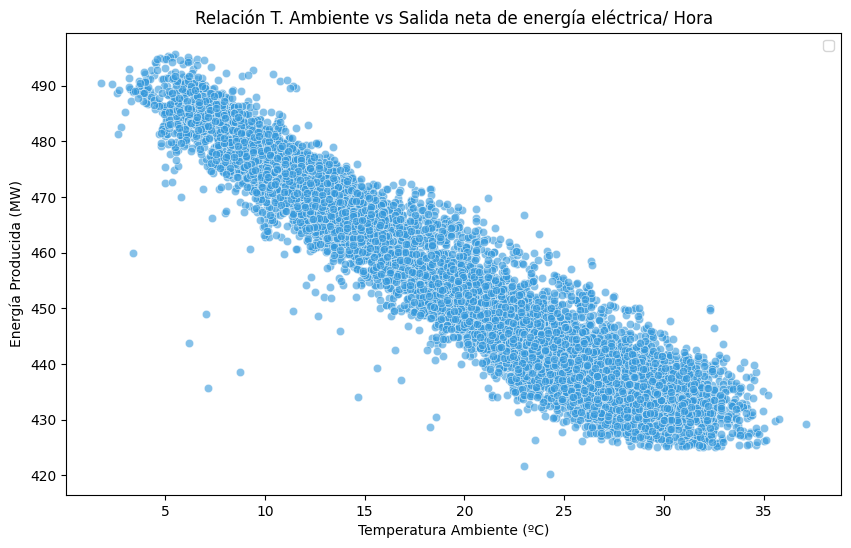

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='AT', y='PE', color='#3498db', alpha=0.6)
plt.title('Relación T. Ambiente vs Salida neta de energía eléctrica/ Hora')
plt.xlabel('Temperatura Ambiente (ºC)')
plt.ylabel('Energía Producida (MW)')
plt.legend()
plt.show()

####**V vs PE**

/tmp/ipykernel_5590/1370347662.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


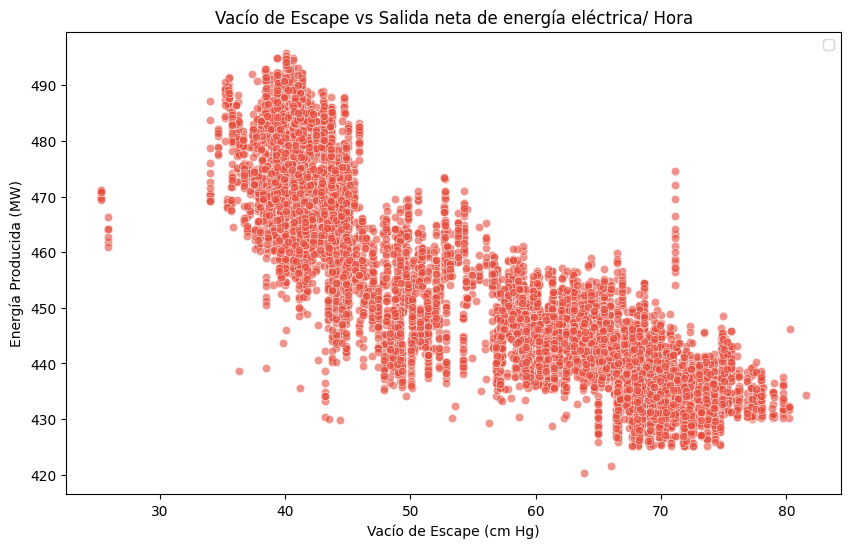

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='V', y='PE', color='#e74c3c', alpha=0.6)
plt.title('Vacío de Escape vs Salida neta de energía eléctrica/ Hora')
plt.xlabel('Vacío de Escape (cm Hg)')
plt.ylabel('Energía Producida (MW)')
plt.legend()
plt.show()

####**AP vs PE**

/tmp/ipykernel_5590/1675150490.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


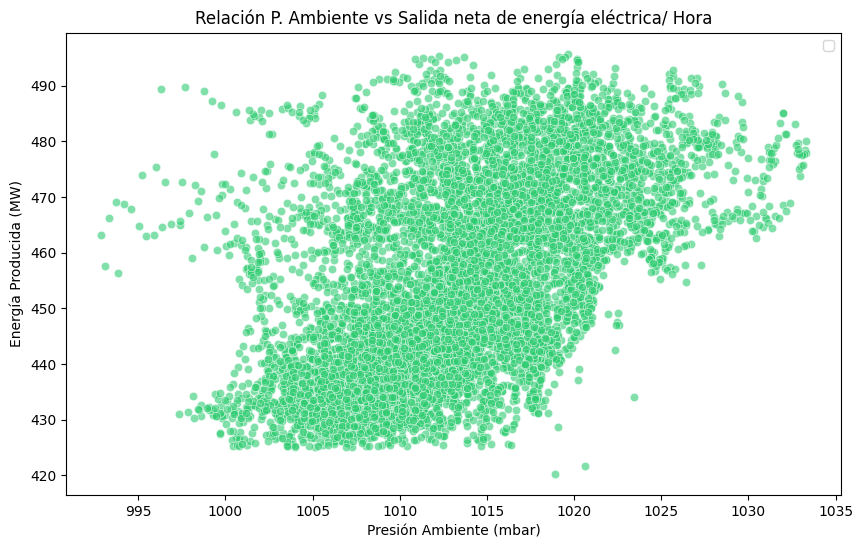

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='AP', y='PE', color='#2ecc71', alpha=0.6)
plt.title('Relación P. Ambiente vs Salida neta de energía eléctrica/ Hora')
plt.xlabel('Presión Ambiente (mbar)')
plt.ylabel('Energía Producida (MW)')
plt.legend()
plt.show()

####**RH vs PE**

/tmp/ipykernel_5590/3835039993.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


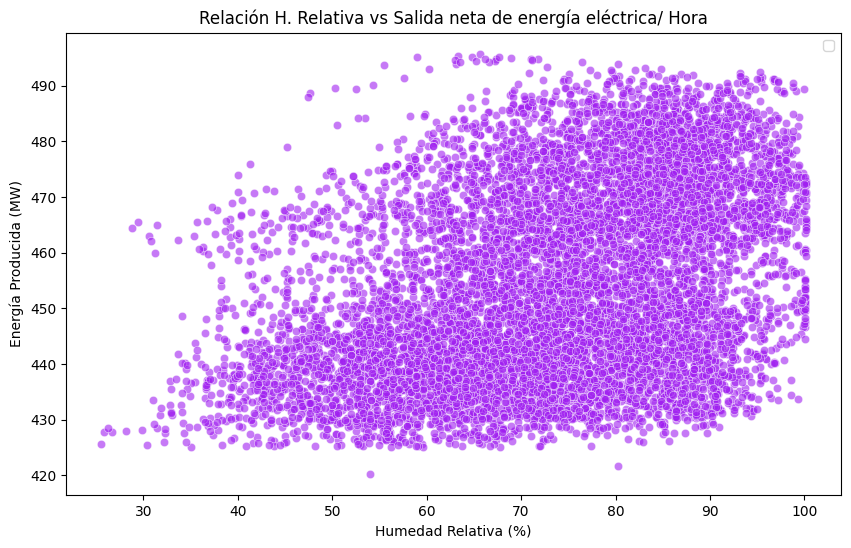

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='RH', y='PE', color='#a020f0', alpha=0.6)
plt.title('Relación H. Relativa vs Salida neta de energía eléctrica/ Hora')
plt.xlabel('Humedad Relativa (%)')
plt.ylabel('Energía Producida (MW)')
plt.legend()
plt.show()

La relación de **PE** con **AT** es notablemente lineal. Sin embargo, en el gráfico de **V** con **PE**, se observa una mayor dispersión. Esto sugiere que para un mismo nivel de vacío, otros factores (como la humedad o la presión) están influyendo.

Por lo que, un modelo lineal simple funcionaría bien para **AT**, pero para capturar la complejidad de **V** y sus interacciones (las **no-linealidades** que puedan haber en el proceso), necesitamos **XGBoost**.

###**Visualización 3. Matriz de Correlación**

Text(0.5, 1.0, 'Matriz de Correlación')

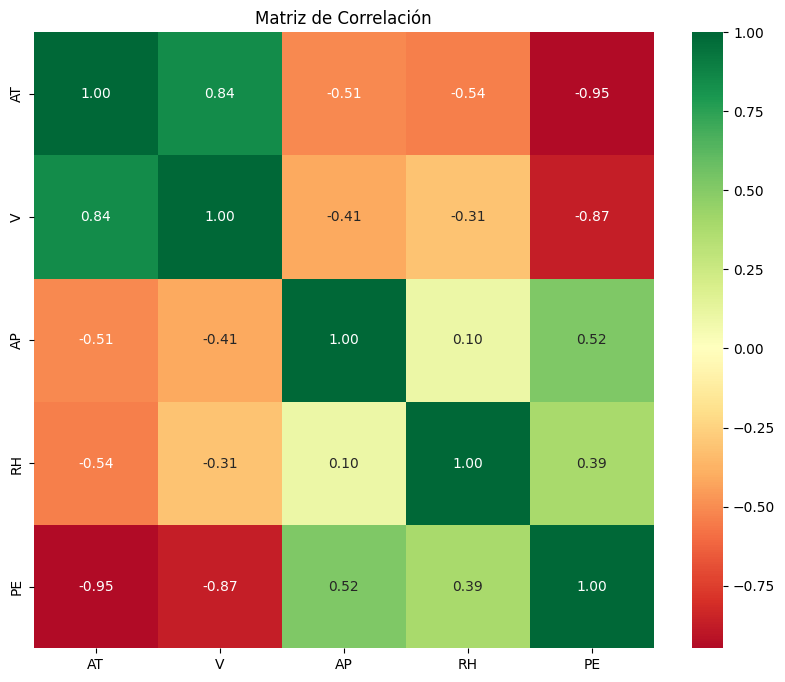

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Matriz de Correlación')

* **AT (-0.95):** Correlación negativa extrema. Partimos de que el aire frío es más denso, permitiendo un mayor flujo másico en la turbina de gas.

* **V (-0.87):** Indica que a medida que el valor de vacío (presión) sube, la energía baja. Un condensador ineficiente mata el rendimiento del ciclo Rankine.

Por lo que sacamos en claro que, **AT** y **V** serán las variables predictoras más potentes. **AP** y **RH** aportan matices, pero no son los motores principales.

A continuación, podemos echar un pequeño vistazo a un resumen del comportamiento de las variables:

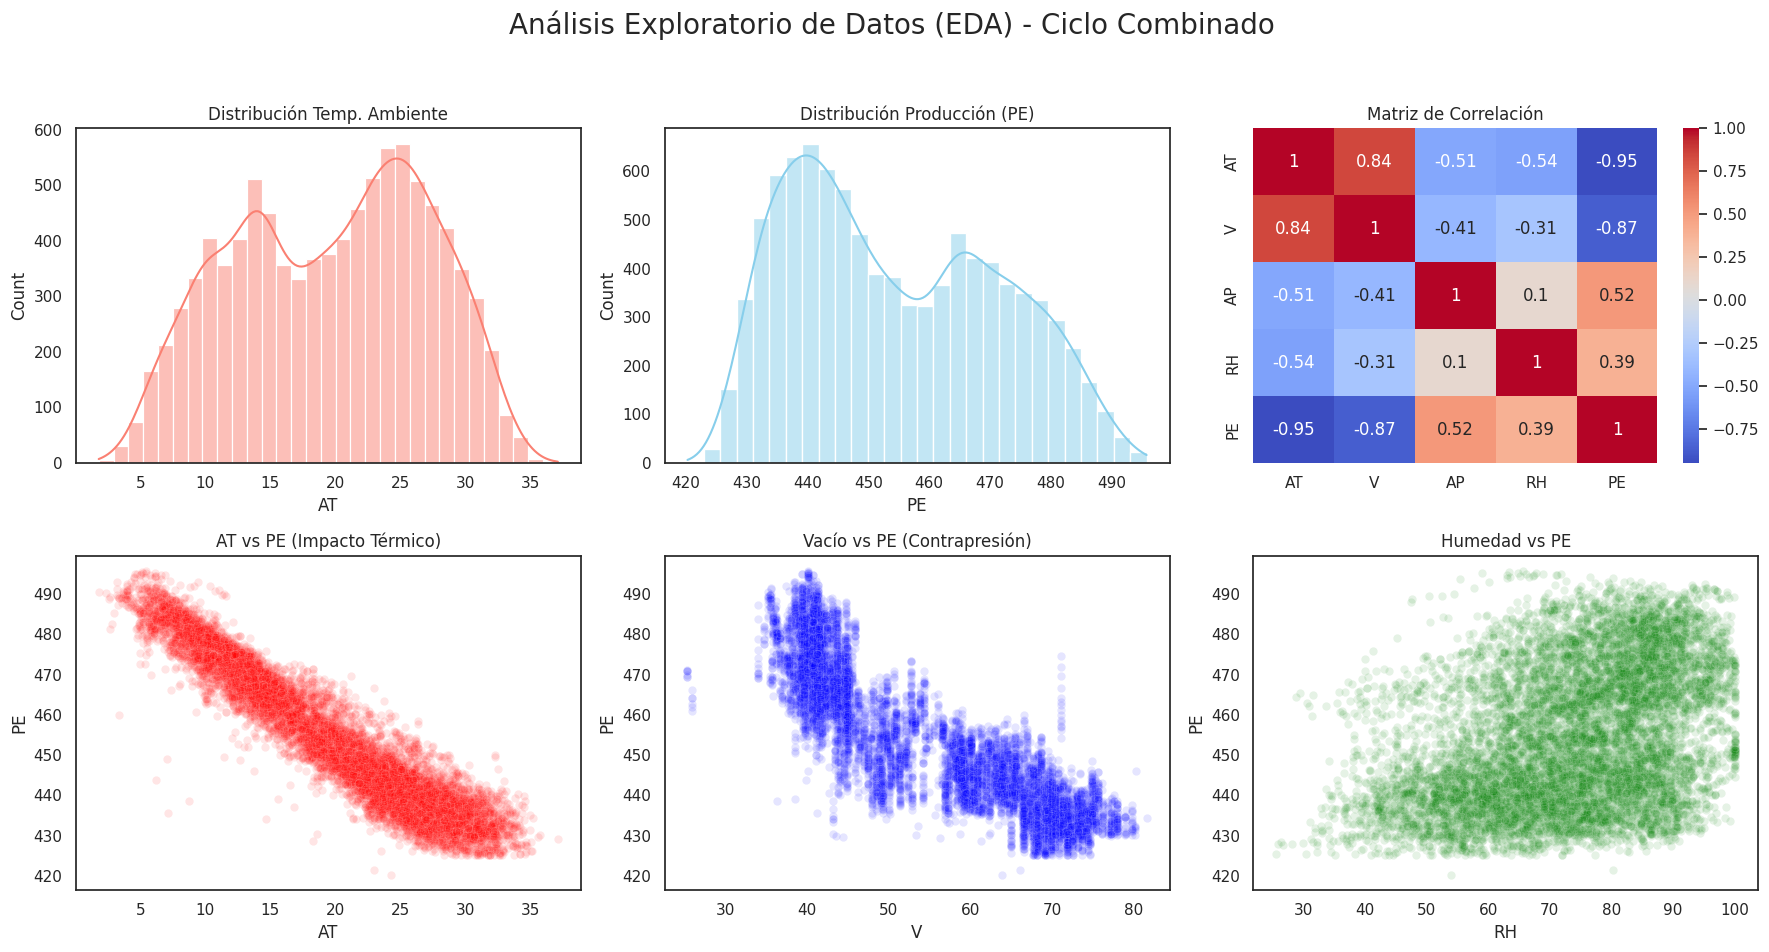

In [11]:
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis Exploratorio de Datos (EDA) - Ciclo Combinado', fontsize=20)

# Histogramas (Distribución)
sns.histplot(df['AT'], kde=True, ax=axes[0, 0], color='salmon').set_title('Distribución Temp. Ambiente')
sns.histplot(df['PE'], kde=True, ax=axes[0, 1], color='skyblue').set_title('Distribución Producción (PE)')

# Heatmap (Correlación)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=axes[0, 2])
axes[0, 2].set_title('Matriz de Correlación')

# Scatter Plots (Relaciones clave)
sns.scatterplot(data=df, x='AT', y='PE', ax=axes[1, 0], alpha=0.1, color='red').set_title('AT vs PE (Impacto Térmico)')
sns.scatterplot(data=df, x='V', y='PE', ax=axes[1, 1], alpha=0.1, color='blue').set_title('Vacío vs PE (Contrapresión)')
sns.scatterplot(data=df, x='RH', y='PE', ax=axes[1, 2], alpha=0.1, color='green').set_title('Humedad vs PE')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##**🏗️ Propuesta de Feature Engineering**

En este apartado, crearemos variables que representen fenómenos físicos reales. En este caso probaremos con 3 diferentes:

* **Índice de Densidad del Aire (`Air_Density_Index`)**

* **Interacción Temperatura-Vacío (`AT_V_Interaction`)**

* **Humedad Específica Estimada(`Specific_Hum_Index`)**

###**Índice de Densidad del Aire (`Air_Density_Index`)**

La eficiencia del condensador (V) depende directamente de la temperatura del foco frío (AT).

In [12]:
# Densidad del aire: Proporcional a P/T (T en Kelvin)
df['Air_Density_Index'] = df['AP'] / (df['AT'] + 273.15)

###**Interacción Temperatura-Vacío (`AT_V_Interaction`)**

La eficiencia del condensador (V) depende directamente de la temperatura del foco frío (AT).

In [13]:
# Interacción Temperatura-Vacío: La capacidad de enfriamiento depende de ambos
df['AT_V_Interaction'] = df['AT'] * df['V']

###**Humedad Específica Estimada(`Specific_Hum_Index`)**

La humedad relativa (RH) por sí sola no dice cuánta agua hay en el aire si no sabemos la temperatura. He usado una aproximación de la presión de saturación de vapor.

In [14]:
# Humedad Específica aproximada: Relaciona humedad relativa con la temperatura de saturación
# (Fórmula empírica para presión de saturación de vapor)
df['Sat_Pressure_Est'] = np.exp((17.27 * df['AT']) / (df['AT'] + 237.3))
df['Specific_Hum_Index'] = df['RH'] * df['Sat_Pressure_Est']

Por último, hacemos de nuevo una visualización de la correlación entre las variables mediante una nueva matriz de correlación:

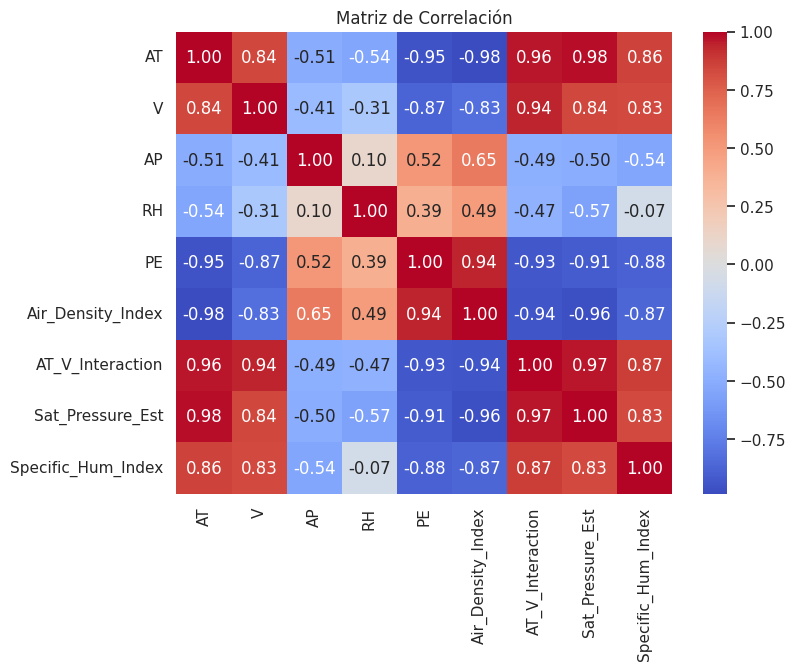


Correlación de las nuevas variables con PE:
PE                    1.000000
Air_Density_Index     0.942751
AT_V_Interaction     -0.934391
Specific_Hum_Index   -0.884037
Name: PE, dtype: float64


In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()
print("\nCorrelación de las nuevas variables con PE:")
print(df[['PE', 'Air_Density_Index', 'AT_V_Interaction', 'Specific_Hum_Index']].corr()['PE'])

Vemos, por lo tanto que,

* La nueva variable (`Air_Density_Index`) tiene una correlación de 0.94 con PE. Capta mejor el efecto combinado de presión y temperatura en la admisión.

* La variable (`AT_V_Interaction`) tiene una correlación de -0.93. Ayuda al modelo a entender que el efecto del vacío no es independiente de la temperatura exterior.

* La variable (`Specific_Hum_Index`) tiene una correlación de -0.88. Es mucho más potente que el simple RH (0.39) original.

###**Análisis de densidades/distribuciones**

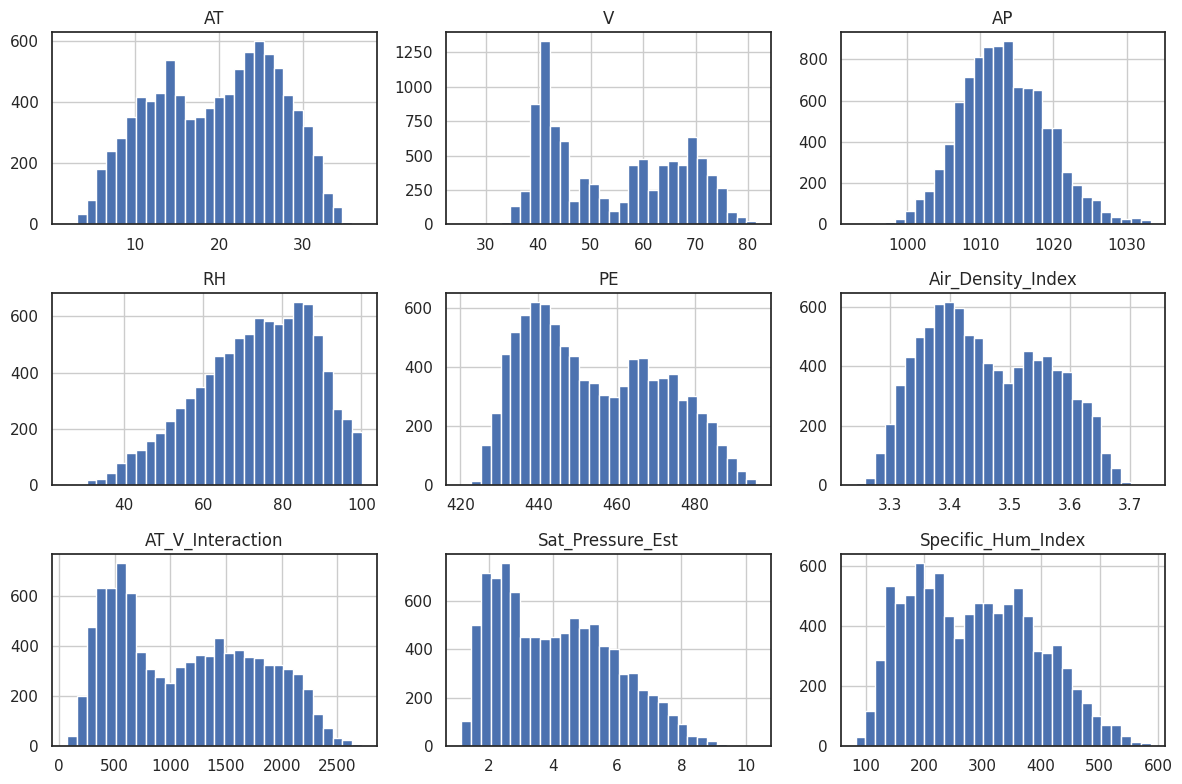

In [16]:
df.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

####*Esto ayuda al modelo por las siguientes razones:*

* **No linealidad explícita:** Los modelos como XGBoost o Random Forest son buenos encontrando patrones, pero si ya le damos la "fórmula" como hemos hecho en este caso (ej. la interacción entre temperatura y vacío), el modelo necesita menos profundidad y menos datos para converger a una solución precisa.

* **Reducción del sesgo:** Al normalizar la relación física entre temperatura y presión, se elimina parte del ruido que el modelo tendría que aprender por sí solo.

##**Fase de Entrenamiento**

###**División de los datos, entrenamiento de XGBoost y evaluación de la precisión**

Reservaremos el 20% de los datos para evaluar "en seco" cómo funciona el modelo con datos que nunca ha visto. A continuación, usaremos XGBRegressor; y por último, mediremos el **RMSE** (para saber cuántos MW fallamos de media) y el **R^2** (para saber qué porcentaje de la variabilidad explicamos).

In [17]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Excluimos las columnas intermedias creadas para la ingeniería de variables
X = df.drop(columns=['PE', 'Sat_Pressure_Est'])
y = df['PE']

# División (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento (XGBoost)
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Evaluación
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Resultados del Modelo:")
print(f"RMSE: {rmse:.4f} MW")
print(f"R²: {r2:.4f}")

Resultados del Modelo:
RMSE: 3.4086 MW
R²: 0.9599


**Análisis de los resultados:**

* **RMSE (3.41 MW):** Esto significa que, en promedio, **el modelo se equivoca por solo 3.41 MW en una producción total de ~450 MW**. **Eso equivale a un error de menos del 0.8%**. Es una precisión excelente para un modelo que solo utiliza variables ambientales.

* **R² (0.9599):** El modelo explica casi el 96% de la variabilidad de la potencia de salida.

###**Importancia de las variables**

In [18]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("\nImportancia de las variables:")
print(feature_importance)


Importancia de las variables:
              Feature  Importance
5    AT_V_Interaction    0.928818
4   Air_Density_Index    0.033550
0                  AT    0.022347
6  Specific_Hum_Index    0.006700
1                   V    0.003809
2                  AP    0.003111
3                  RH    0.001666


La variable llamada `AT_V_Interaction`, que es el resultado de la combinación de la Temperatura y el vacío, **domina el modelo con un 90% de importancia.**

##**¿Cómo pasamos a la Optimización Prescriptiva?**

El objetivo no es predecir lo que va a pasar, sino buscar el punto de operación que maximice la energía **($PE$)** para unas condiciones ambientales dadas.

Sabemos que no se puede controlar la temperatura ambiente **($AT$)** o la presión ambiente **($AP$)**, pero sí se pueden controlar variables de operación como el Vacío de escape **($V$)** (a través de la gestión de bombas de circulación o limpieza de condensadores).

A continuación, la estrategia que se seguirá, será la de optimización por **búsqueda de máximo**. Se utilizará la librería ´scipy.optimize´ para encontrar, para cualquier par de condiciones dadas **($AT, AP, RH$)**, qué valor de **$V$** maximiza la salida de energía según nuestro modelo ya entrenado.

In [19]:
from scipy.optimize import minimize

def optimizar_operacion(at, ap, rh, model):
    """
    Busca el valor de V (Vacío) que maximiza la potencia (PE).
    Nota: minimize busca el mínimo, así que minimizamos -PE.
    """
    # Definimos la función objetivo negativa (para maximizar PE)
    def funcion_a_minimizar(v_test):
        # Reconstruimos las features necesarias para el modelo
        v = v_test[0]
        # Crear los inputs (misma estructura que el entrenamiento)
        air_density = ap / (at + 273.15)
        at_v_inter = at * v
        # Aproximación de Humedad específica
        sat_pressure = np.exp((17.27 * at) / (at + 237.3))
        spec_hum = rh * sat_pressure

        # Crear array para el modelo
        features = np.array([[at, v, ap, rh, air_density, at_v_inter, spec_hum]])

        # Retornamos el negativo de la predicción
        return -model.predict(features)[0]

    # Límites físicos para el Vacío (según dataset original)
    limites = [(25.36, 81.56)]

    # Punto de partida (media del dataset)
    x0 = [54.3]

    resultado = minimize(funcion_a_minimizar, x0, bounds=limites, method='SLSQP')

    return resultado.x[0], -resultado.fun

# Ejemplo de uso:
at_actual = 25.0
ap_actual = 1013.0
rh_actual = 70.0

v_optimo, pe_maximo = optimizar_operacion(at_actual, ap_actual, rh_actual, model)

print(f"Para condiciones actuales: AT={at_actual}°C, AP={ap_actual}mbar")
print(f"El Vacío ideal (V) es: {v_optimo:.2f} cmHg")
print(f"Potencia máxima esperada: {pe_maximo:.2f} MW")

Para condiciones actuales: AT=25.0°C, AP=1013.0mbar
El Vacío ideal (V) es: 54.30 cmHg
Potencia máxima esperada: 446.28 MW


Por lo que se puede ver, obtenemos un dato de Vacío óptimo ($V$) de 54.30 cmHg en tiempo real, permitiendo maximizar la eficiencia térmica independientemente de las condiciones atmosféricas fluctuantes.

##**Validación del modelo en la app**

Al probar el despliegue de nuestro modelo en streamlit, se puede ver que el modelo de XGBoost no ha capturado una relación clara de "curva" en $V$ que le permita al optimizador encontrar un mínimo claro distinto de su punto de partida.

Es decir, el modelo no ve una "curva de eficiencia" clara para $V$, sino que ve una relación lineal o dependiente de la temperatura. Por lo tanto, se comprobará la importancia de las variables a ver si eso es así:

In [21]:
print(model.feature_importances_)

[0.02234672 0.00380864 0.00311068 0.00166584 0.03355014 0.9288179
 0.00670005]


###**Prueba de Sensibilidad del modelo**

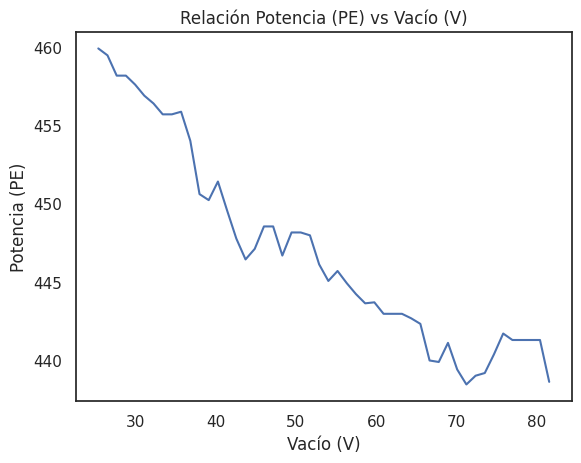

In [22]:
import matplotlib.pyplot as plt

# Fijamos condiciones ambientales constantes
at_fija, ap_fija, rh_fija = 25.0, 1013.0, 70.0
valores_v = np.linspace(25.36, 81.56, 50)
predicciones = []

for v in valores_v:
    # Debes recrear exactamente las mismas features que usaste al entrenar
    air_density = ap_fija / (at_fija + 273.15)
    at_v_inter = at_fija * v
    sat_pressure = np.exp((17.27 * at_fija) / (at_fija + 237.3))
    spec_hum = rh_fija * sat_pressure

    features = np.array([[at_fija, v, ap_fija, rh_fija, air_density, at_v_inter, spec_hum]])
    predicciones.append(model.predict(features)[0])

plt.plot(valores_v, predicciones)
plt.title("Relación Potencia (PE) vs Vacío (V)")
plt.xlabel("Vacío (V)")
plt.ylabel("Potencia (PE)")
plt.show()

Nuestro modelo de XGBoost (y los árboles de decisión en general) no crean funciones matemáticas "suaves" (como una parábola), sino que crean aproximaciones a base de escalones. Al no tener una curva suave, el optimizador no ve un "valle" o una "cima" donde pararse, sino una pendiente constante.

Por otro lado, el dashboard nos devuelve siempre el valor de V óptimo de 50 cmHg porque (tal y como se puede ver en la imagen anterior) la función es una línea recta; por lo tanto, el optimizador SLSQP no encuentra un óptimo matemático (donde la derivada sea cero). En muchos casos de implementación, cuando el algoritmo "no sabe qué hacer" porque la función es demasiado plana, simplemente devuelve el valor de inicio (x0) que se le da.

Por lo tanto, para hacer frente a esta problemática, se entrenarán 3 nuevos modelos:

* `RandomForestRegressor`
* `GradientBoostingRegressor`
* `Modelo de regresión con polinomios`

Conceptualmente, esto es lo que pasará con cada uno de los 3 modelos:

* **Random Forest Regressor:** Al igual que XGBoost, está basado en árboles. Sin embargo, al promediar las predicciones de cientos de árboles independientes (Bagging), la superficie de respuesta suele ser un poco más "suave" que la de XGBoost, aunque seguirá teniendo pequeñas mesetas planas.

* **Gradient Boosting Regressor:** Es similar a XGBoost en concepto (Boosting), pero la implementación de Scikit-Learn a veces genera transiciones ligeramente distintas. Veremos si sufre el mismo problema de "escalones".

* **Regresión Polinómica:** Este es el enfoque clásico de la ingeniería. Transforma las variables en potencias (ej. $V^2$, $AT^2$, $AT \cdot V$) y ajusta una regresión lineal. Esto genera una función matemática continua y completamente diferenciable (una curva suave). Para los optimizadores basados en gradiente como SLSQP, este modelo es el "paraíso" porque siempre hay una pendiente clara que seguir.

##**Entrenamiento de los 3 modelos**

In [23]:
# Importación de las librerías

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# A. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# B. Gradient Boosting (Scikit-Learn)
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

# C. Regresión Polinómica (Grado 2 para evitar sobreajuste y mantener curvas suaves)
poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_model.fit(X_train, y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False)),
                ('linearregression', LinearRegression())])

###**Prueba de sensibilidad comparativa**

In [ ]:
# Fijamos condiciones ambientales promedio
at_fija, ap_fija, rh_fija = 25.0, 1013.0, 70.0
valores_v = np.linspace(25.36, 81.56, 100)

# Listas para guardar las predicciones de cada modelo
pred_xgb = []
pred_rf = []
pred_gb = []
pred_poly = []

for v in valores_v:

    # Recreamos las variables de ingeniería idénticas al entrenamiento
    air_density = ap_fija / (at_fija + 273.15)
    at_v_inter = at_fija * v
    sat_pressure = np.exp((17.27 * at_fija) / (at_fija + 237.3))
    spec_hum = rh_fija * sat_pressure

    # Vector de características (Asegurarnos de que el orden coincide con el X_train)
    features = np.array([[at_fija, v, ap_fija, rh_fija, air_density, at_v_inter, spec_hum]])

    # Predecimos con cada modelo (model es el modelo XGBoost original)
    pred_xgb.append(model.predict(features)[0])
    pred_rf.append(rf_model.predict(features)[0])
    pred_gb.append(gb_model.predict(features)[0])
    pred_poly.append(poly_model.predict(features)[0])

###**Gráfica comparativa**

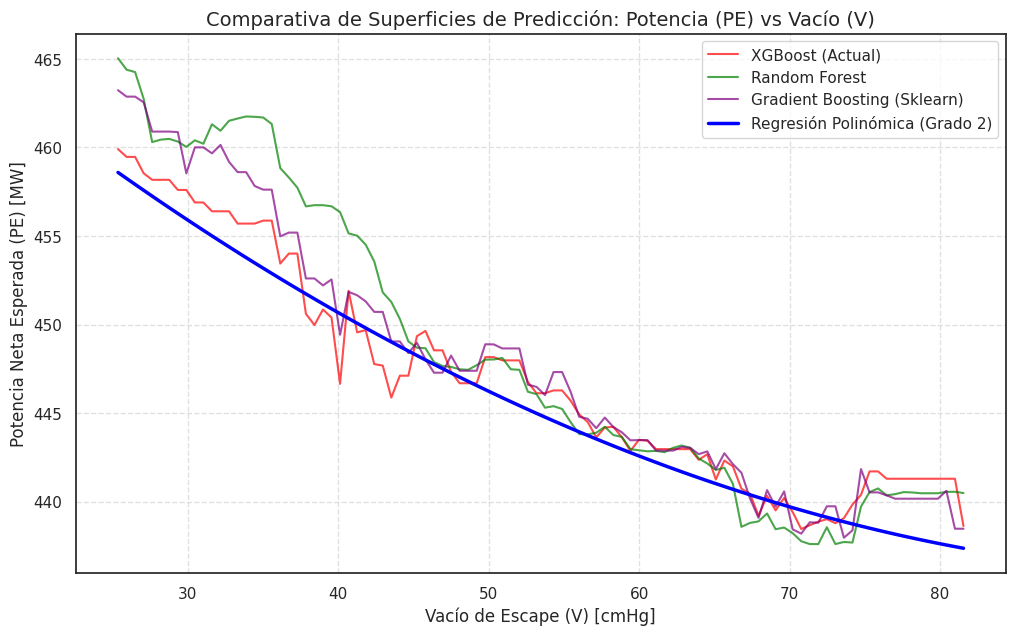

In [25]:
plt.figure(figsize=(12, 7))
plt.plot(valores_v, pred_xgb, label='XGBoost (Actual)', color='red', alpha=0.7)
plt.plot(valores_v, pred_rf, label='Random Forest', color='green', alpha=0.7)
plt.plot(valores_v, pred_gb, label='Gradient Boosting (Sklearn)', color='purple', alpha=0.7)
plt.plot(valores_v, pred_poly, label='Regresión Polinómica (Grado 2)', color='blue', linewidth=2.5)

plt.title("Comparativa de Superficies de Predicción: Potencia (PE) vs Vacío (V)", fontsize=14)
plt.xlabel("Vacío de Escape (V) [cmHg]", fontsize=12)
plt.ylabel("Potencia Neta Esperada (PE) [MW]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

Como esos modelos se basan en árboles, sus predicciones cambian a base de "saltos". Si el optimizador empieza en x0 = 50.00 y cae en una de esas micro-mesetas donde la línea es completamente plana, el algoritmo SLSQP calcula la derivada y si ve que es cero, pensará que ha alcanzado el punto óptimo y no se moverá de ese valor. Estaba atrapado en una trampa numérica debido a la falta de suavidad del modelo.

La regresión polinómica (la línea azul) ha eliminado todo el ruido y nos muestra la tendencia matemática real. Al ser una función continua y suave, no tiene trampas.

Si ahora mismo ejecutamos el optimizador (dashboard de Streamlit) utilizando el modelo polinómico (poly_model) para maximizar la potencia, veremos que ya no se queda en 50.00. Se irá directo al límite inferior del slider (25.36 cmHg), porque ahí es donde la línea azul alcanza su punto más alto.

En una planta de ciclo combinado, el vacío del condensador ($V$) está íntimamente ligado a la presión de condensación de la turbina de vapor. Técnicamente:

* A menor presión en el condensador (lo que el dataset registra como valores bajos de la variable $V$), mayor es el salto entálpico en la turbina de vapor.

* Mayor salto entálpico se traduce directamente en más megavatios (MW) generados.

###**Evaluación del modelo polinómico**

In [26]:
# Evaluación
y_pred = poly_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Resultados del Modelo:")
print(f"RMSE: {rmse:.4f} MW")
print(f"R²: {r2:.4f}")

Resultados del Modelo:
RMSE: 4.1060 MW
R²: 0.9419


##**Comparación final: `poly_model` vs `model`**

###**🏗️ Análisis técnico de las métricas**

* **[texto del enlace](https://)$R^2$ de 0.9419 (94.19%):** Tu XGBoost original explicaba cerca del 96% de la varianza. Con el modelo polinómico de grado 2 hemos bajado un ~1.8%. Sigue siendo una puntuación extraordinariamente alta para un entorno industrial. Significa que el modelo lineal-polinómico entiende casi a la perfección la termodinámica de la planta.

* **RMSE de 4.1060 MW:** El error cuadrático medio es de unos 4.1 megavatios. Si miramos las gráficas anteriores, la planta opera en un rango de entre 435 MW y 465 MW. Un error de 4 MW representa aproximadamente un 1% de error relativo. En cualquier planta de generación eléctrica, una predicción con un 1% de margen de error es un modelo totalmente válido y seguro.

En conclusión, elegimos finalmente el modelo lineal polinómico; ya que, a pesar de sacrificar ese 1-2% en la explicabilidad de la varianza y perder un poco de precisión predictiva, genera una función matemática continua y suave. Es el rey de la prescripción. Al optimizador le resulta facilísimo encontrar el camino hacia el valor ideal porque la superficie no tiene "trampas" ni micro-escalones. Como puede pasar con modelos basados en árboles.